In [1]:
import os
import neurovoc
import tempfile
import librosa

import numpy as np
import matplotlib.pyplot as plt
import scipy
from IPython.display import Audio

import utils_demo as utils

In [2]:
n_fft = 512
hops = 32

n_mels = 64
min_freq = 150
max_freq = 10_500
mel_scale = librosa.filters.mel_frequencies(n_mels, fmin=min_freq, fmax=max_freq)

root = "../data"

### Simple Spectrogram

(64, 1983)


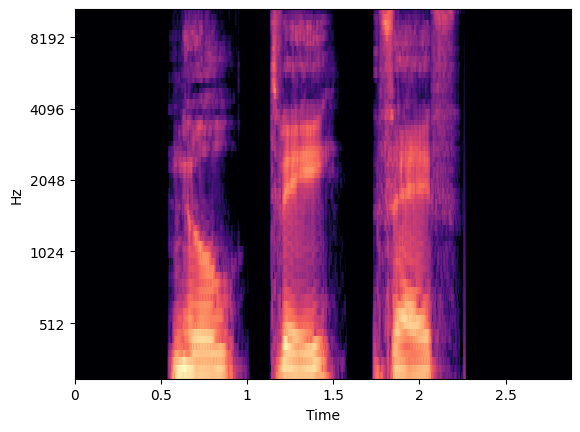

In [3]:
soundname_025 = "din/triplets/025.wav"
filename_025 = os.path.join(root, soundname_025)
y, sr = librosa.load(filename_025)


S_db = utils.get_melspectrogram(y, sr, n_fft, hops)
print(S_db.shape)
librosa.display.specshow(S_db, x_axis='time',
                         y_axis='mel', sr=sr,
                          fmin=min_freq, fmax=max_freq, 
                         n_fft=n_fft, hop_length=hops)

## Run Neurovoc Encoder with Specres

### Original Spectrogram vs Neurogram

In [4]:
def create_specres_neurogram(soundfile):
    filename = os.path.join(root, soundfile)
    y, sr = librosa.load(filename)
    S_db = utils.get_melspectrogram(y, sr, n_fft, hops)

    neurogram = neurovoc.specres(filename, n_trials=1)
    
    utils.plot_spectro_vs_neurogram(S_db, y, neurogram, sr, hops, soundfile)  
    
    return neurogram

## Run Neurovoc Decoder

### Reconstruct CI sound

In [5]:
def reconstruct(neurogram, soundfile):
    reconstructed = neurovoc.reconstruct(neurogram)
    
    filename = os.path.join(root, soundfile)
    original, fs = librosa.load(filename, sr=None)
    reconstructed = scipy.signal.resample(reconstructed, original.size)

    neurovoc.audio_vs_reconstructed(
        original,
        reconstructed,
        fs,
        len(neurogram.frequencies),
        neurogram.min_freq, 
        neurogram.max_freq, 
    )
    
    plt.show()
    
    utils.plot_and_play_reconstructed(original, reconstructed, fs, mel_scale, soundfile)
    return reconstructed

#### Bird song

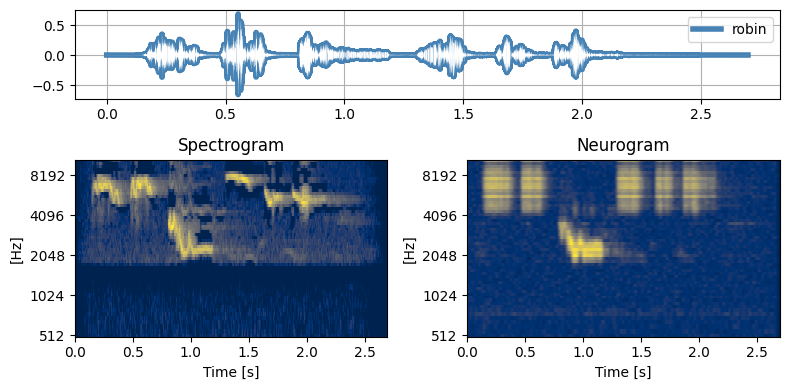

In [6]:
soundname_robin = "robin.wav"
neurogram_robin = create_specres_neurogram(soundname_robin)

The frequency alignment of the model is appropriate, due to the ‘learned‘
frequencies. 

Lower temporal precision due to CIS, which requires that all electrode pairs be stimulated
for a single cycle of the strategy

Moreover, since there is only one electrode pair that stimulates signals over 4 248 Hz (see Table 2 in the Appendix),
there is very little precision for high-frequency stimuli

![alt text](neurocov_table2_analysis_bands_freq_bounds.png)

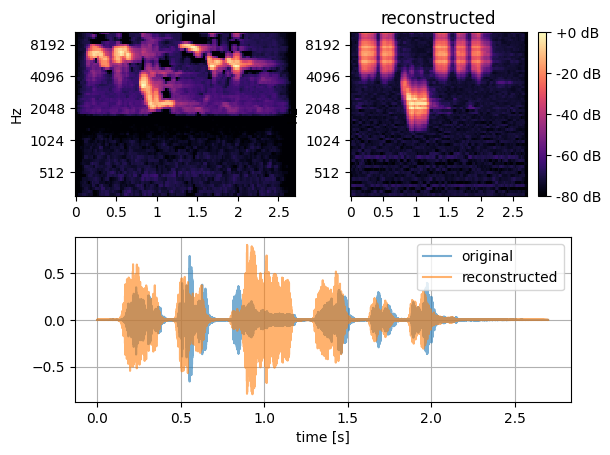

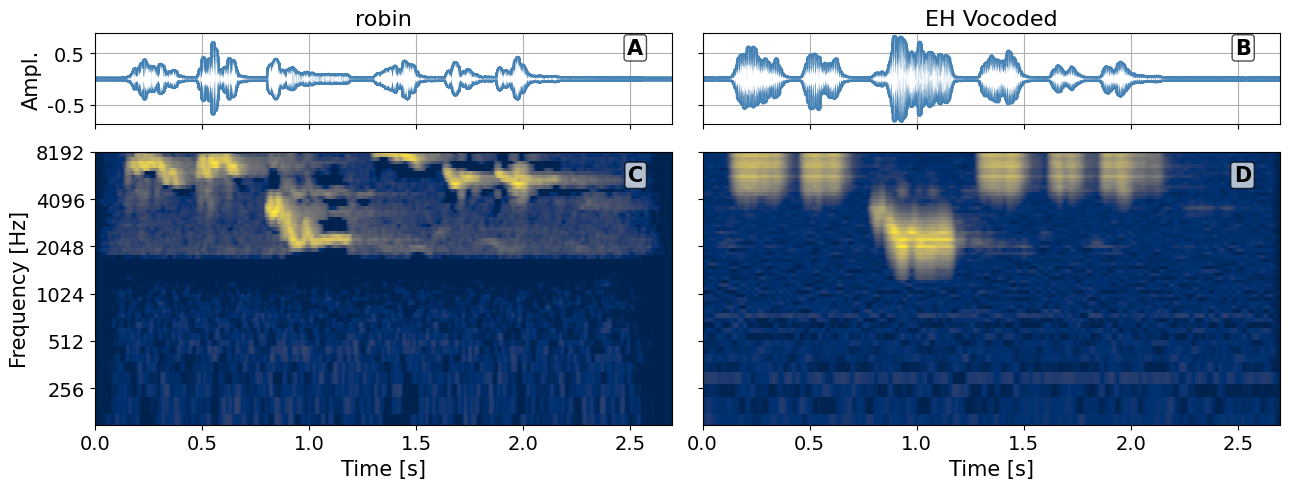

In [7]:
reconstructed_robin = reconstruct(neurogram_robin, soundname_robin)

#### Choice

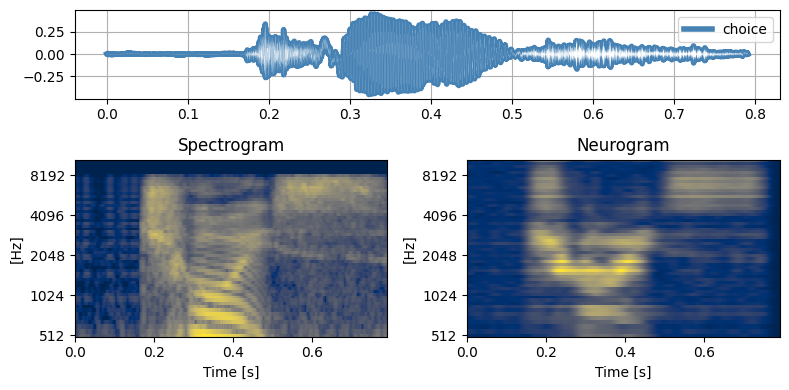

In [8]:
soundname_choice = "choice.wav"
neurogram_choice = create_specres_neurogram(soundname_choice)

c:\Users\agk\AppData\Local\anaconda3\envs\phast_dev\Lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


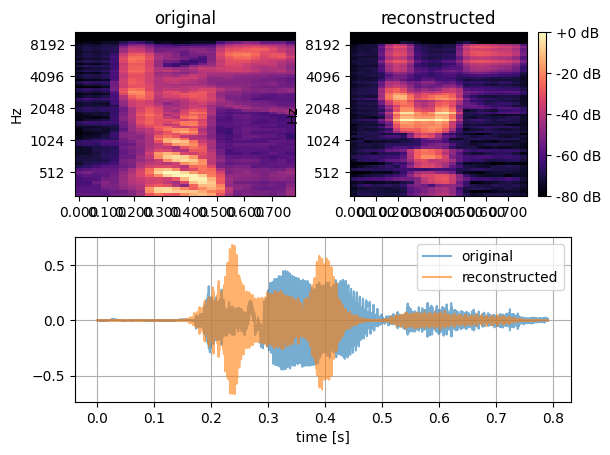

c:\Users\agk\AppData\Local\anaconda3\envs\phast_dev\Lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


array([ 0.00017544, -0.0003825 , -0.00023263, ..., -0.00048726,
        0.00011257,  0.0002044 ], shape=(12655,), dtype=float32)

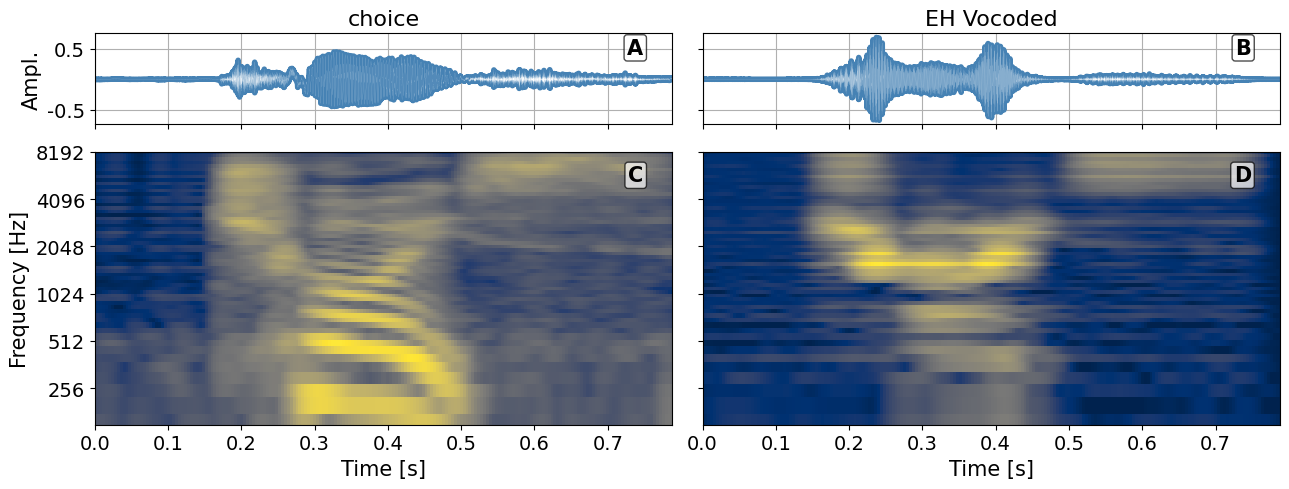

In [9]:
reconstruct(neurogram_choice, soundname_choice)

#### Time domain analysis
 - The timing of the reconstructed signal is well aligned with the original.

 - The amplitude is not. 

#### Spectrogram analysis

 - substantial spectral degradation
 - the limited bandwidth and the coarser frequency binning of the SCS in the CI model
 - especially evident for higher frequencies, transmitted by a single electrode contact, which causes a smearing in the spectrogram

### TODO

Also channel interaction, caused by current spread in the cochlea, further degrades frequency selectivity.
Because electrical stimulation from one electrode can spread and activate
adjacent auditory nerve regions, the effective independence between channels
is reduced, leading to overlapping neural excitation patterns and a blurring
of spectral details.

#### Choice with Noise at SNR -4db

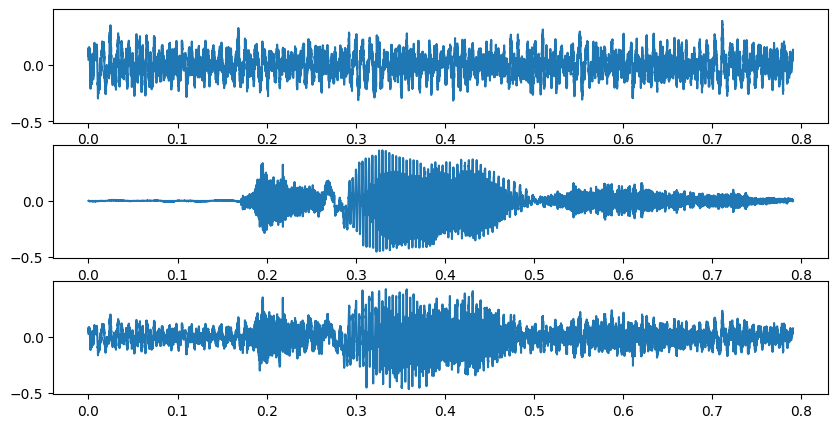

In [10]:
soundname_choice_4db_snr = utils.mix_sound_with_noise(soundname_choice, snr=4)

## TODO graph titles

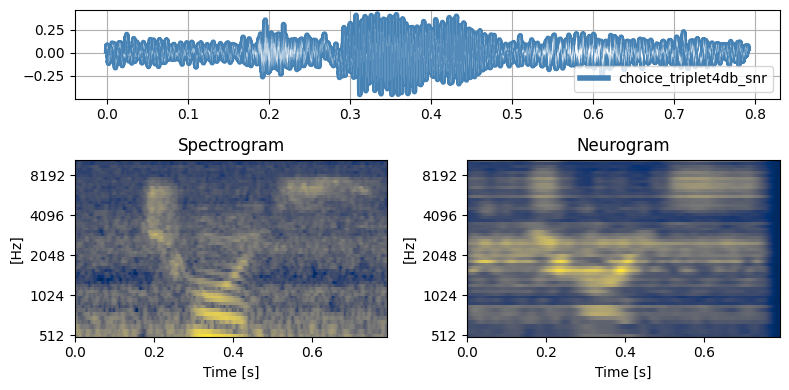

In [11]:
neurogram_choice_4db_snr = create_specres_neurogram(soundname_choice_4db_snr)

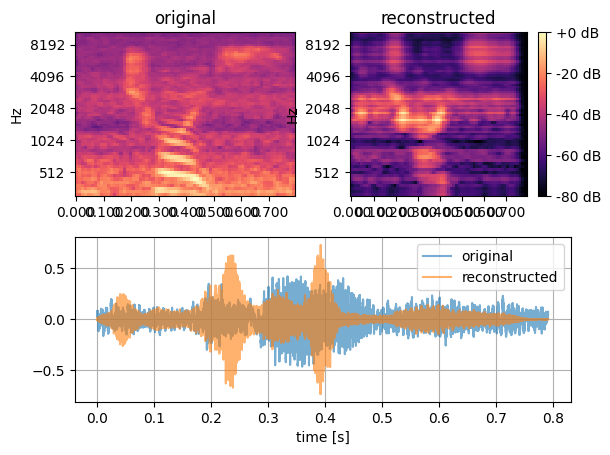

array([-5.1856637e-03, -3.7475575e-03,  2.4393408e-03, ...,
        2.6952906e-04,  1.3090292e-04,  1.6149006e-05],
      shape=(34881,), dtype=float32)

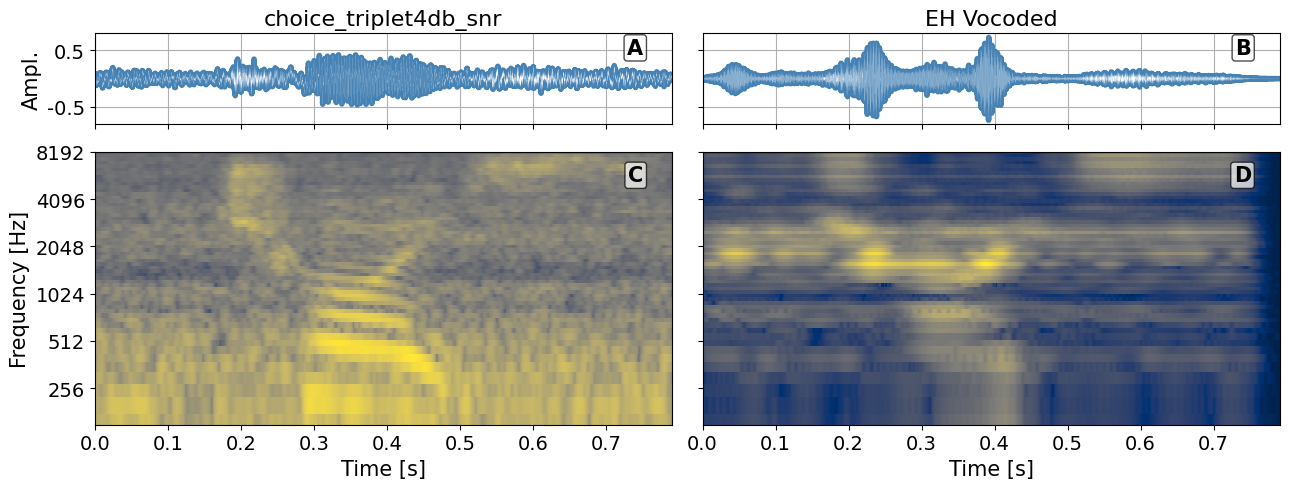

In [ ]:
reconstruct(neurogram_choice_4db_snr, soundname_choice_4db_snr)

### TODO ms one float

#### Time domain analysis

 - The mismatch in amplitude between the original and reconstructed signals persists
 - SIgnificant for the amplitude at the beginning of the signal compared with the amplitude at the end of the reconstructed signal, which both should only contain noise. Specifically, the EH vocoder produces a much larger amplitude at the onset than the (input) signal strength alone would suggest

#### Spectrogram analysis
# TODO
 - In contrast, this refractory-driven modulation is less evident in the EH
vocoder (Figure 7F). However, the impact of noise manifests differently:
channel interaction becomes substantially more pronounced. Specifically, the
spectral smearing in the mid-frequency range (approximately 1 000–3 000 Hz)
increases, causing certain frequency bands to become overemphasized. This
leads to a suppression of finer spectral details and a loss of clarity in the
reconstructed signal.
Overall, the added noise has a more detrimental effect on the EH model
than on the NH model. This is consistent with real-world observations:
cochlear implant (CI) users are generally more affected by noisy environments
than normal-hearing listeners (Cullington and Zeng, 2008). The vocoder reconstructions
mirror this limitation, reinforcing that the EH model captures
key perceptual challenges CI users face.


#### Digits in Dutch

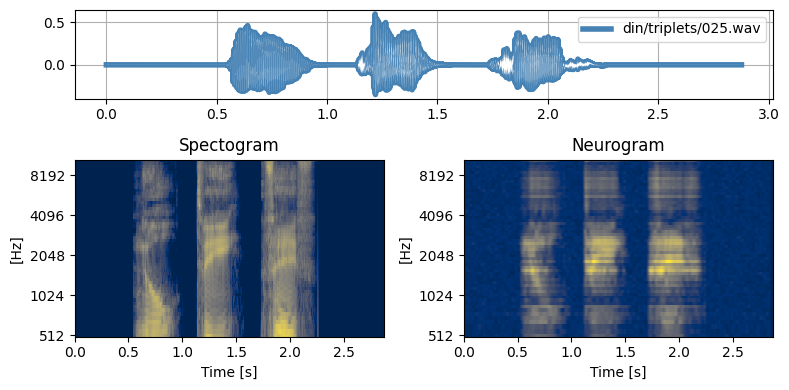

In [18]:
neurogram_025 = create_specres_neurogram(soundname_025)

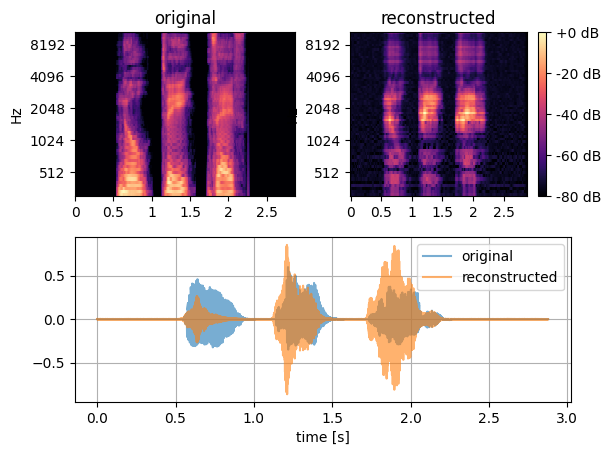

array([ 1.7898837e-04, -4.5692792e-05, -3.5672847e-04, ...,
        3.3790397e-04,  8.8918576e-05, -5.5024734e-06],
      shape=(126885,), dtype=float32)

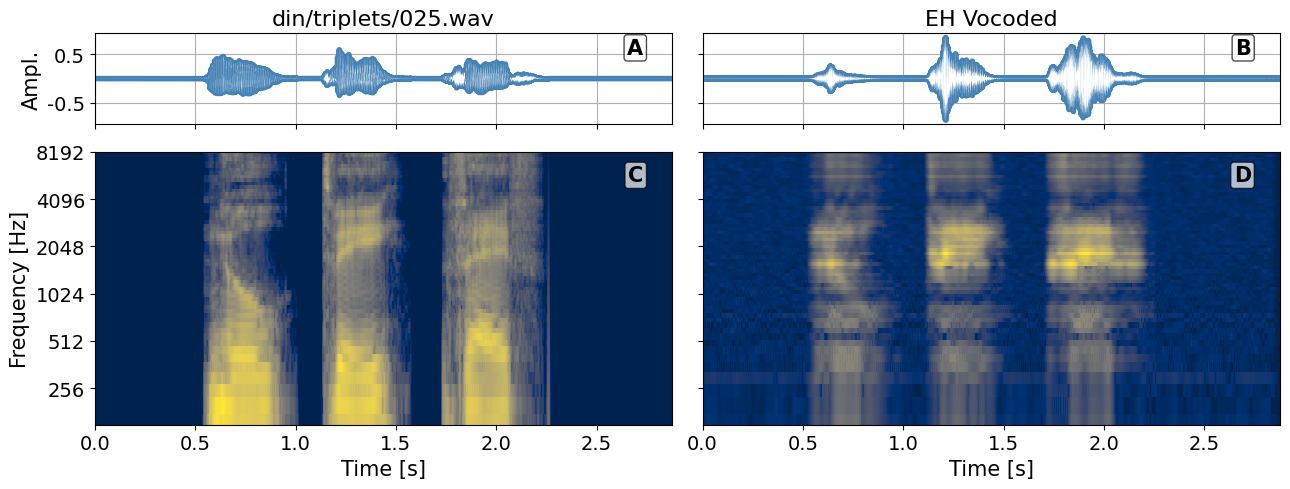

In [34]:
reconstruct(neurogram_025, soundname_025)

#### Sinusoidal 440 Hz at 0.8 amplitude 0dB tone mixed with white noise of amplitude 0.3 at -16 dB

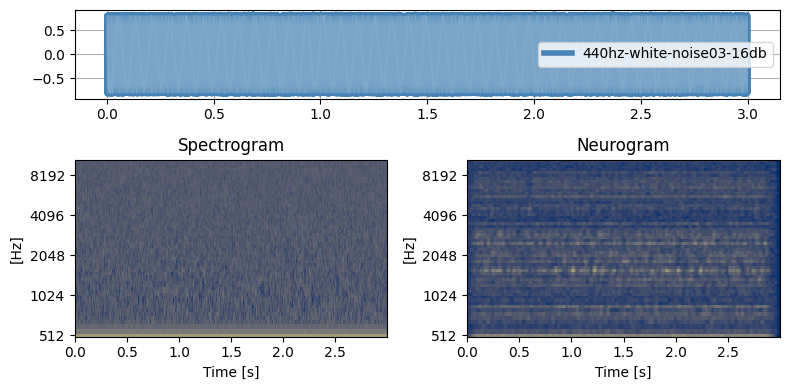

In [13]:
# Todo generate sines here

soundname_noise_16 = "440hz-white-noise03-16db.wav"
neurogram_noise_16 = create_specres_neurogram(soundname_noise_16)

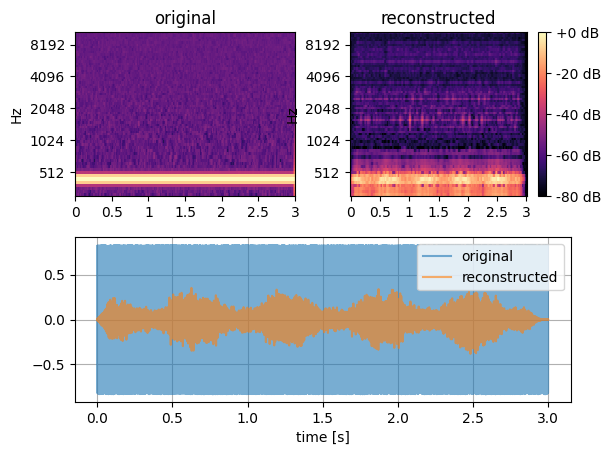

array([ 1.6219832e-03,  7.1358081e-04, -8.6780643e-04, ...,
        2.2612994e-05,  4.1764102e-05,  8.4886388e-08],
      shape=(132300,), dtype=float32)

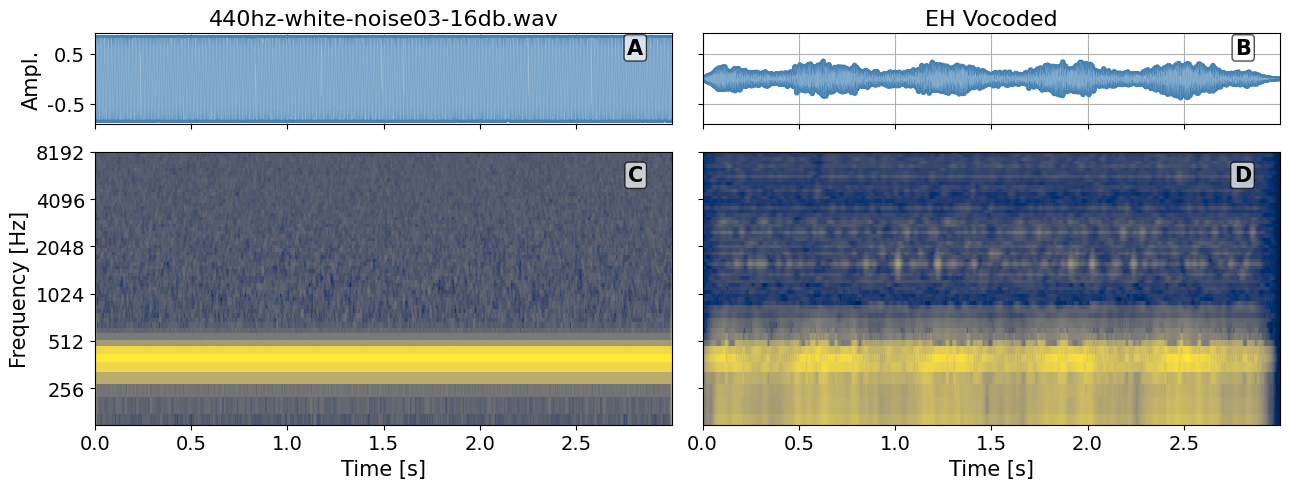

In [35]:
reconstruct(neurogram_noise_16, soundname_noise_16)

#### Sinusoidal 440 Hz tone at 0.8 amplitude 0dB mixed with white noise of amplitude 0.3 at -28 dB

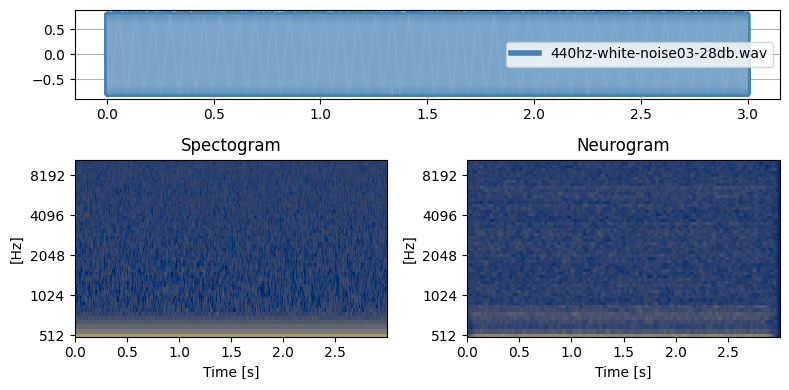

In [28]:
soundname_noise_28 = "440hz-white-noise03-28db.wav"
neurogram_noise_28 = create_specres_neurogram(soundname_noise_28)

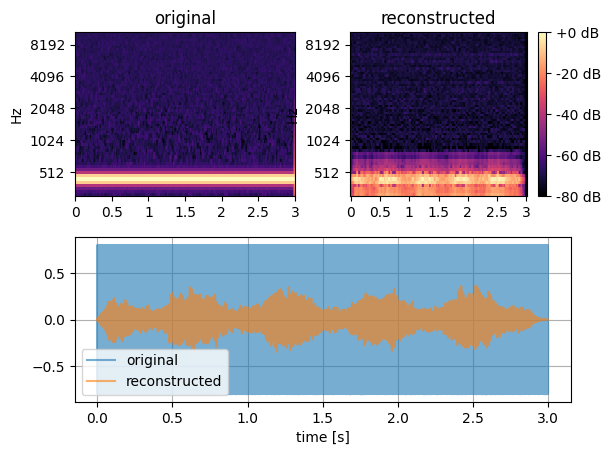

array([ 1.0155058e-02,  1.3111525e-02,  1.0638154e-02, ...,
       -8.0001730e-05, -4.4949185e-05,  3.9859694e-07],
      shape=(132300,), dtype=float32)

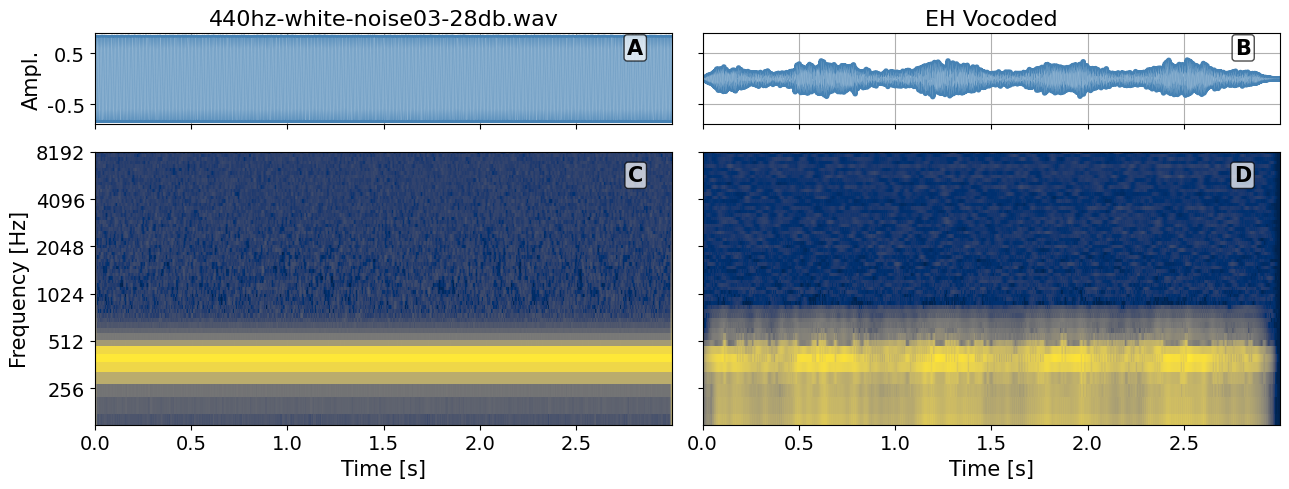

In [36]:
reconstruct(neurogram_noise_28, soundname_noise_28)

#### Sinusoidal 220 Hz tone at 0.8 amplitude 0dB mixed with white noise of amplitude 0.3 at -28 dB

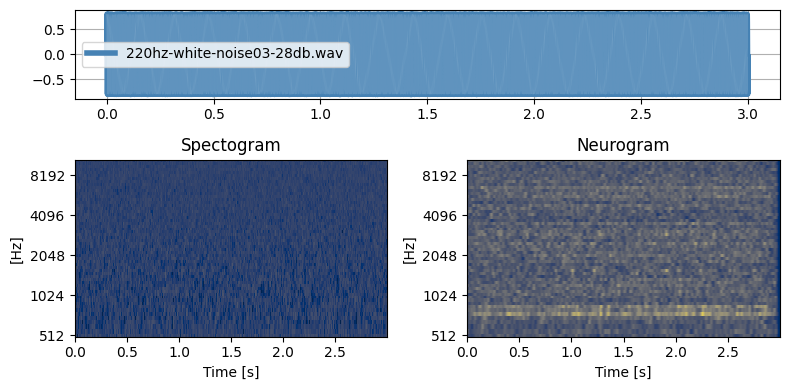

In [37]:
soundname_noise_220hz_28 = "220hz-white-noise03-28db.wav"
neurogram_noise_220hz_28 = create_specres_neurogram(soundname_noise_220hz_28)

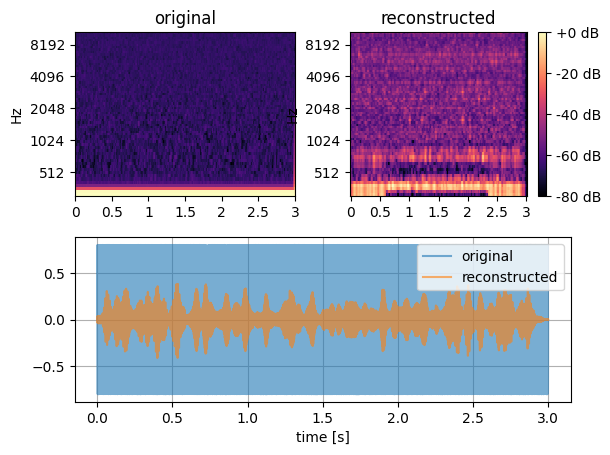

array([2.1182081e-02, 2.9319717e-02, 2.8295759e-02, ..., 6.5901360e-05,
       8.7174623e-05, 7.8981247e-07], shape=(132300,), dtype=float32)

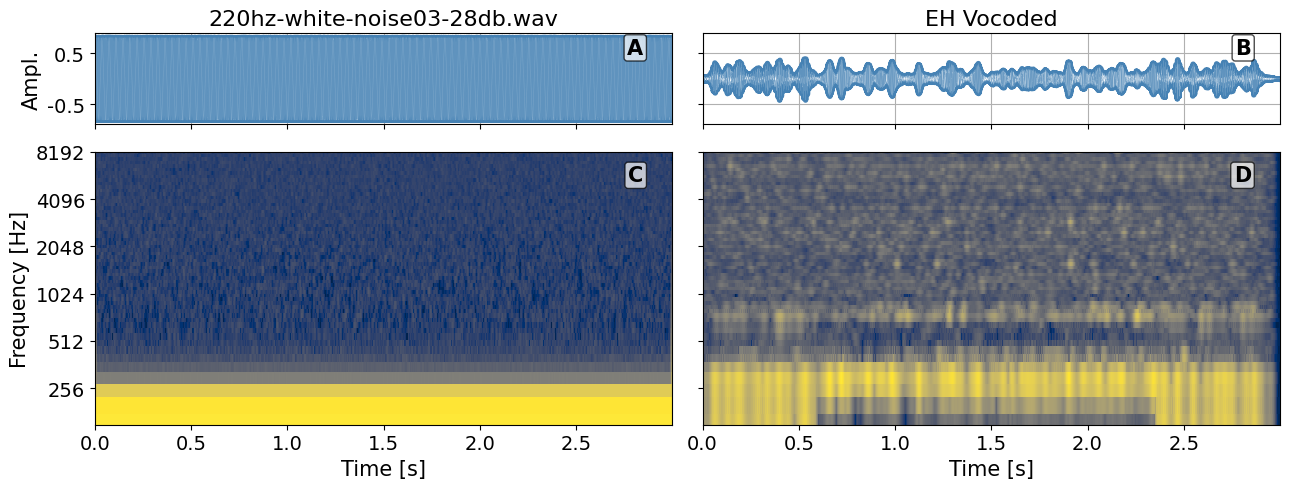

In [31]:
reconstruct(neurogram_noise_220hz_28, soundname_noise_220hz_28)

#### Sinusoidal 110 Hz tone at 0.8 amplitude 0dB mixed with white noise of amplitude 0.3 at -28 dB

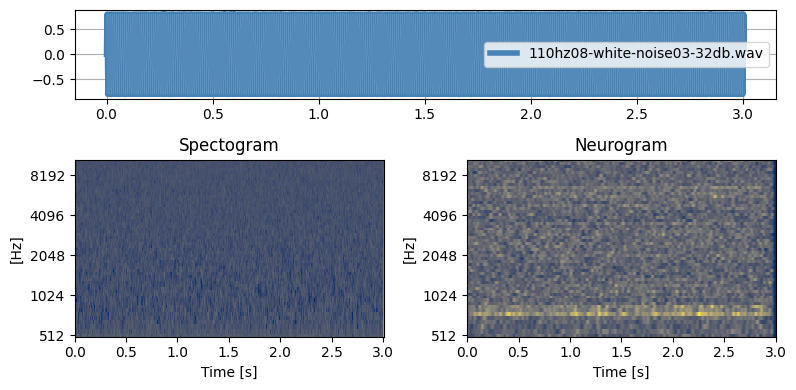

In [38]:
soundname_noise_110hz_32db = "110hz08-white-noise03-32db.wav"
neurogram_noise_110hz_32db = create_specres_neurogram(soundname_noise_110hz_32db)

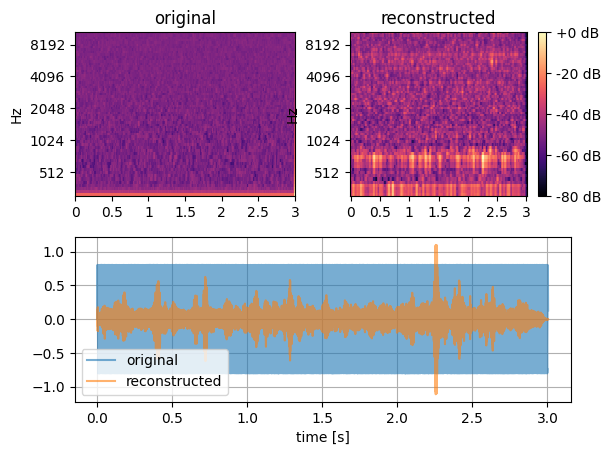

array([-0.0131732 , -0.02034652, -0.02309664, ...,  0.00170155,
        0.00123063,  0.00041112], shape=(132491,), dtype=float32)

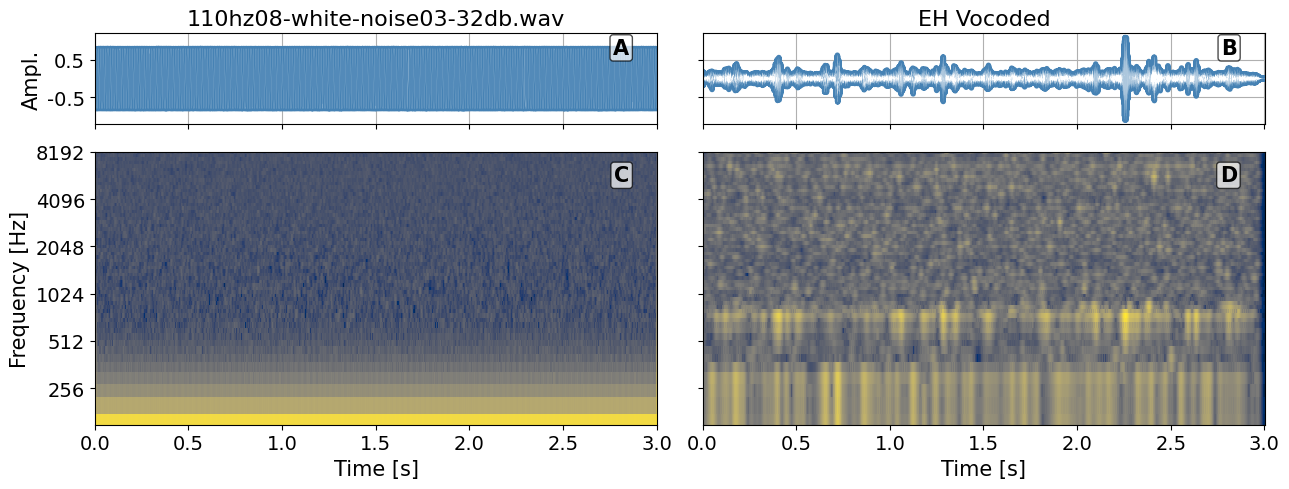

In [39]:
reconstruct(neurogram_noise_110hz_32db, soundname_noise_110hz_32db)